In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import datasets, models
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from tqdm import tqdm
from PIL import Image

In [11]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda:1


In [12]:
class TrashDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Keep deterministic ordering and ignore non-files (hidden files, directories)
        self.file_list = sorted([f for f in os.listdir(root_dir) if os.path.isfile(os.path.join(root_dir, f))])
        
        # Create a mapping for labels to numbers
        # e.g., {'cardboard': 0, 'plastic': 1}
        self.label_map = {"cardboard": 0, "plastic": 1, "glass": 2, "metal": 3, "paper": 4, "trash": 5}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        
        # Extract label from filename: train_cardboard_000.jpg -> cardboard
        parts = img_name.split('_')
        if len(parts) > 1:
            label_str = parts[1]
        else:
            # fallback in case filename doesn't match expected pattern
            label_str = 'trash'
        label = self.label_map.get(label_str, self.label_map['trash'])

        if self.transform:
            image = self.transform(image)

        return image, label


# Load the base dataset (pass None for transform initially)
train_dataset = TrashDataset(root_dir='data/train', transform=None)
test_dataset = TrashDataset(root_dir='data/test',transform=None)


In [13]:
# Define your augmentation pipeline
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # Resize slightly larger first
    
    # --- DATA AUGMENTATION STARTS HERE ---
    transforms.RandomResizedCrop(224),  # Randomly zoom and crop to 224x224
    transforms.RandomHorizontalFlip(),  # 50% chance to flip the image
    transforms.RandomRotation(15),      # Rotate by +/- 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Slight color shifts
    # --- DATA AUGMENTATION ENDS HERE ---
    
    transforms.ToTensor(),              # Convert to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [14]:
# A small helper class to apply transforms to the subsets
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Create the final datasets
# Validation should use a deterministic transform (no random augmentations)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_data = ApplyTransform(train_dataset, transform=train_transform)
val_data = ApplyTransform(test_dataset, transform=val_transform)

# Use a small number of workers for faster loading; pin_memory helps when using CUDA
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_data)} | Val: {len(val_data)}")


Train: 3985 | Val: 1704


Image tensor shape: torch.Size([3, 224, 224])
Label index: 0 (Name: cardboard)


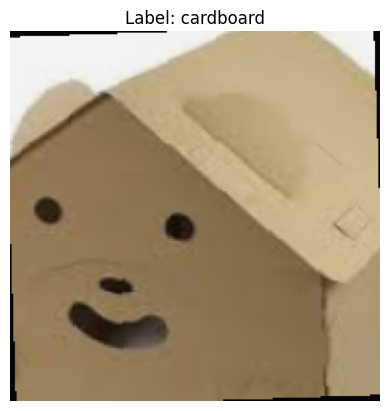

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

def _find_label_map(ds):
	"""
	Robustly search common wrapper attributes for a label_map dict.
	Looks at attributes like .label_map, .dataset, .subset and also inspects
	attribute values to handle custom wrappers.
	"""
	q = deque([ds])
	seen = set()
	while q:
		cur = q.popleft()
		if cur is None:
			continue
		cur_id = id(cur)
		if cur_id in seen:
			continue
		seen.add(cur_id)

		if hasattr(cur, 'label_map'):
			return getattr(cur, 'label_map')

		# common wrapper attributes that may contain the underlying dataset
		for attr in ('dataset', 'subset', 'ds', 'base', 'datasets'):
			if hasattr(cur, attr):
				try:
					val = getattr(cur, attr)
					q.append(val)
				except Exception:
					pass

		# also inspect __dict__ values (helps with some custom wrappers)
		if hasattr(cur, '__dict__'):
			for v in cur.__dict__.values():
				q.append(v)

	raise AttributeError("Could not find 'label_map' on the provided dataset or its wrappers")

# 1. Access the first item (ApplyTransform will apply transforms when indexing)
image_tensor, label_idx = train_data[0]

# 2. Locate the label_map robustly
label_map_source = _find_label_map(train_data)

# build inverse mapping: index -> name
inv_label_map = {v: k for k, v in label_map_source.items()}

# ensure label index is an int (sometimes a tensor)
label_idx_int = int(label_idx)

label_name = inv_label_map[label_idx_int]

# 3. Print stats
print(f"Image tensor shape: {image_tensor.shape}") 
print(f"Label index: {label_idx_int} (Name: {label_name})")

# 4. Display
# move to cpu if needed and convert to numpy
img_np = image_tensor.cpu().permute(1, 2, 0).numpy()

# Un-normalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_to_show = std * img_np + mean
img_to_show = np.clip(img_to_show, 0, 1)

plt.imshow(img_to_show)
plt.title(f"Label: {label_name}")
plt.axis('off')
plt.show()

In [16]:
from IPython.display import clear_output
import time
import copy
import torch
import numpy as np
from tqdm import tqdm

def train_model_dynamic(model, train_loader, val_loader, criterion, optimizer, num_epochs=25, patience=5):
    since = time.time()

    # Track history
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    log_messages = [] # We will store text logs here

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_acc = 0.0
    epochs_no_improve = 0
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    for epoch in range(num_epochs):
        
        # --- DYNAMIC DISPLAY SECTION ---
        clear_output(wait=True) # Clear the previous output
        
        # Print the Dashboard
        print(f"=== Training Dashboard ===")
        print(f"Epoch: {epoch+1}/{num_epochs}")
        print(f"Best Val Acc: {best_acc:.4f}")
        print(f"Patience Used: {epochs_no_improve}/{patience}")
        print(f"Time Elapsed: {(time.time() - since):.0f}s")
        print("-" * 30)
        
        # Print the last 5 lines of history so you can see the trend
        print("Recent History:")
        for msg in log_messages[-5:]:
            print(msg)
        print("-" * 30)
        # -------------------------------

        # Each epoch has a training and validation phase
        epoch_results = [] # To store temp strings for this epoch
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Progress bar
            iter_bar = tqdm(dataloader, desc=phase, leave=False)
            
            for inputs, labels in iter_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar with current loss
                iter_bar.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            # Save result string
            result_msg = f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}'
            epoch_results.append(result_msg)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_loss)

                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_model.pth')
                    epoch_results.append(" [Saved Best Model!]")
                else:
                    epochs_no_improve += 1
        
        # Add this epoch's results to the log
        log_messages.append(f"Ep {epoch+1}: " + " | ".join(epoch_results))

        # Early Stopping check
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs!')
            break

    # Final Summary
    clear_output(wait=True)
    print("=== Training Complete ===")
    print(f"Total Time: {(time.time() - since) // 60:.0f}m {(time.time() - since) % 60:.0f}s")
    print(f"Best Val Acc: {best_acc:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, history, best_acc

In [17]:
model = models.resnet101(weights='DEFAULT')

# robustly get label_map (works with ApplyTransform and other wrappers)
try:
    label_map = _find_label_map(train_data)
except Exception:
    # fallback checks for common attributes
    if hasattr(train_data, 'subset') and hasattr(train_data.subset, 'label_map'):
        label_map = train_data.subset.label_map
    elif hasattr(train_dataset, 'label_map'):
        label_map = train_dataset.label_map
    else:
        raise

num_classes = len(label_map)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_model, history, best_acc = train_model_dynamic(model, train_loader, val_loader, criterion, optimizer, num_epochs=1000, patience=15)

print(f"Training finished with best validation accuracy: {best_acc:.4f}")

=== Training Complete ===
Total Time: 26m 43s
Best Val Acc: 0.9448
Training finished with best validation accuracy: 0.9448


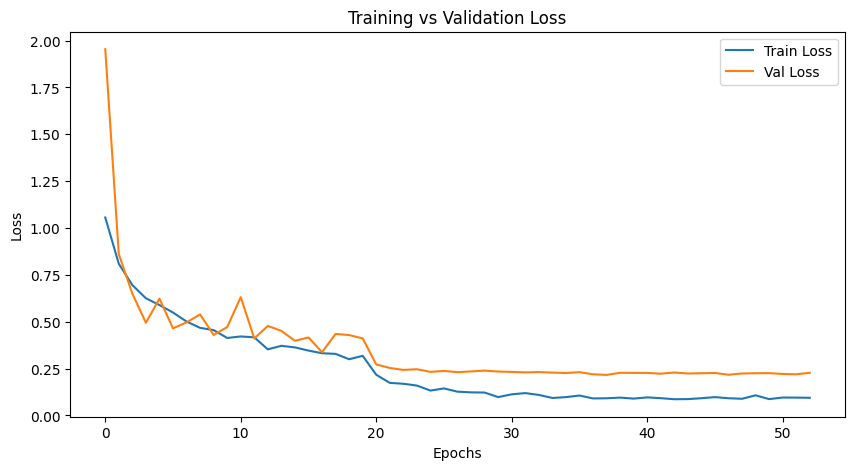

Training finished with best validation accuracy: 0.9448


In [19]:
# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"Training finished with best validation accuracy: {best_acc:.4f}")


       OVERALL METRICS
Overall Accuracy:  0.9448
Overall Precision: 0.9452
Overall Recall:    0.9448
Overall F1-Score:  0.9448
------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

   cardboard     0.9846    0.9659    0.9751       264
     plastic     0.9253    0.8849    0.9047       252
       glass     0.9645    0.9533    0.9589       428
       metal     0.9099    0.9422    0.9258       225
       paper     0.9525    0.9678    0.9601       311
       trash     0.9095    0.9420    0.9254       224

    accuracy                         0.9448      1704
   macro avg     0.9410    0.9427    0.9417      1704
weighted avg     0.9452    0.9448    0.9448      1704



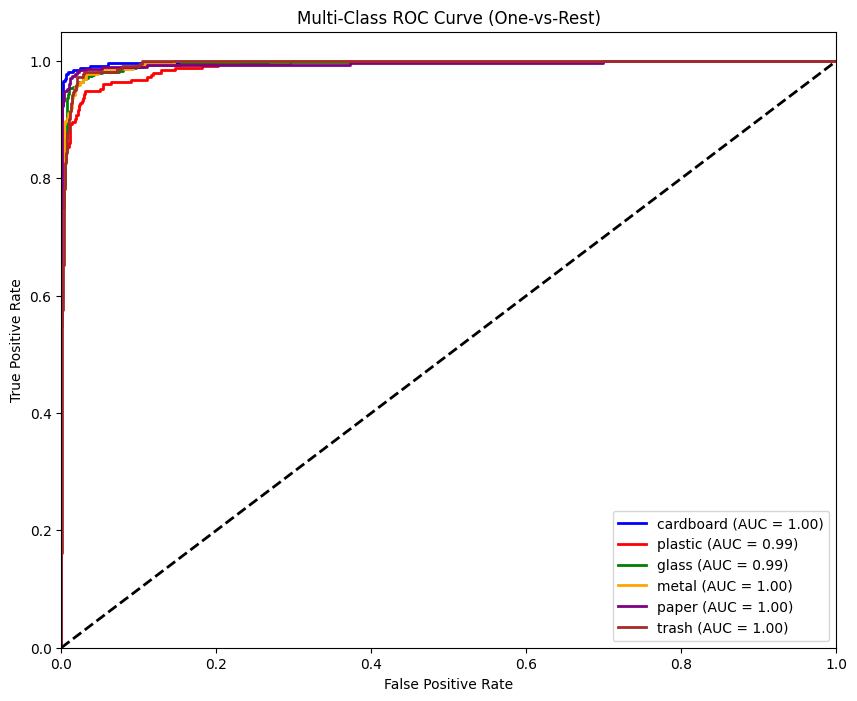

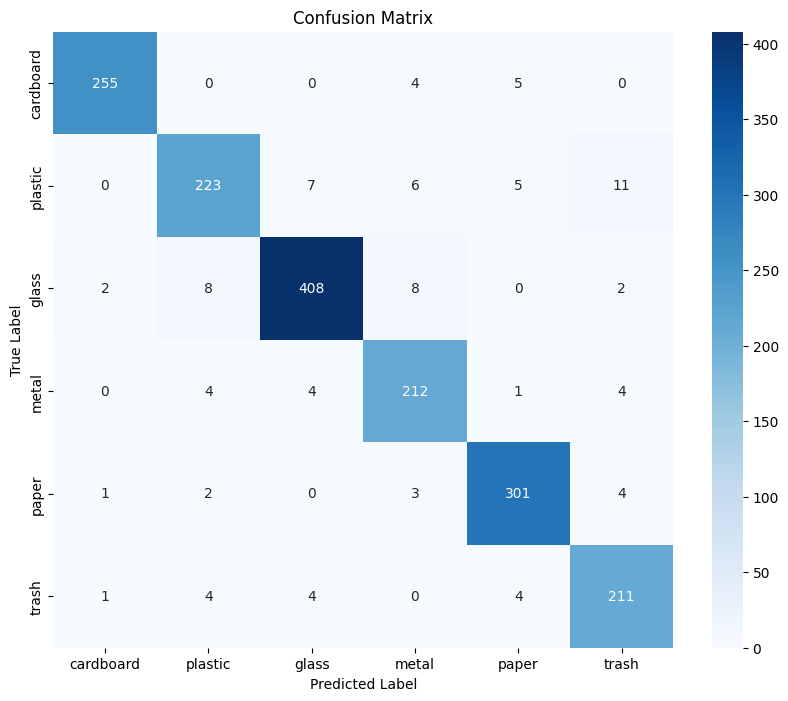

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Ensure the model is in evaluation mode
best_model.eval()

# 1. Collect all Predictions (Probabilities) and True Labels
y_true = []
y_scores = [] # We need raw probabilities for ROC, not just the final class

print("Collecting predictions on validation set...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Get raw outputs (logits)
        outputs = best_model(inputs)
        
        # Apply Softmax to get probabilities (0.0 to 1.0)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# 2. Get Class Names
# Robustly get label map
try:
    if 'label_map' not in locals():
         if hasattr(train_dataset, 'label_map'):
             label_map = train_dataset.label_map
         else:
             # Fallback
             label_map = {"cardboard": 0, "plastic": 1, "glass": 2, "metal": 3, "paper": 4, "trash": 5}
except:
    pass

# Sort class names by index
classes = [k for k, v in sorted(label_map.items(), key=lambda item: item[1])]
n_classes = len(classes)

# 3. Calculate Overall Metrics (Hard Predictions)
y_pred = np.argmax(y_scores, axis=1) # Convert probs to hard class predictions

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
acc = accuracy_score(y_true, y_pred)

print("\n" + "="*30)
print("       OVERALL METRICS")
print("="*30)
print(f"Overall Accuracy:  {acc:.4f}")
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall:    {recall:.4f}")
print(f"Overall F1-Score:  {f1:.4f}")
print("-" * 30)

# 4. Print Detailed Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# 5. ROC Curve and AUC (One-vs-Rest)
# Binarize the true labels (e.g., class 0 becomes [1, 0, 0, 0, 0, 0])
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, 
            yticklabels=classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()